In [1]:
import pandas as pd

rfm = pd.read_csv(
    "../data/processed/rfm_customers.csv"
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled[:5]

ModuleNotFoundError: No module named 'sklearn'

In [1]:
import pandas as pd

rfm = pd.read_csv("../data/processed/rfm_customers.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,0.00
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled[:5]

array([[ 2.32202285, -0.32936215, -0.23041952],
       [-0.89373323,  0.20610242,  0.29405454],
       [-0.1691956 , -0.11517632, -0.01171748],
       [-0.72500529, -0.43645506, -0.01654727],
       [ 2.16322008, -0.43645506, -0.18972715]])

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,2,0.00,1
1,12347.0,2,7,4310.00,3
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,3
4,12350.0,310,1,334.40,1


In [4]:
rfm["Cluster"].value_counts()

Cluster
3    3091
1    1077
0     193
2      11
Name: count, dtype: int64

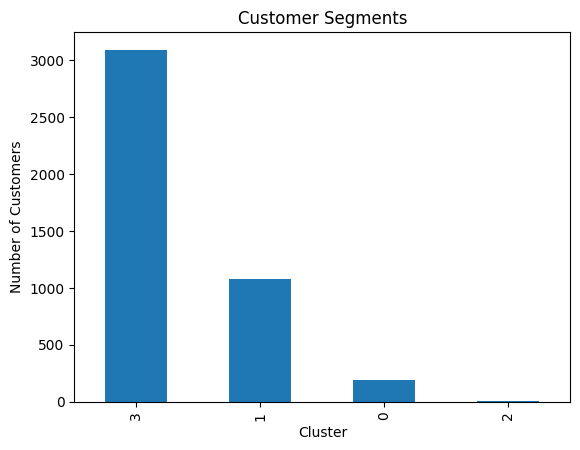

In [5]:
import matplotlib.pyplot as plt

rfm["Cluster"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [6]:
rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,10.787565,28.575130,12190.961710
1,248.927577,1.805942,453.425572
2,5.090909,109.909091,124150.432727
3,42.768360,4.374313,1317.266164


In [7]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

In [8]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

rfm["DBSCAN"] = dbscan.fit_predict(
    rfm_scaled
)

In [9]:
rfm["DBSCAN"].value_counts()

DBSCAN
 0    4326
-1      46
Name: count, dtype: int64

In [10]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)